# E-Commerce Exploratory Data Analysis

## Project: E-Commerce Competitive Pricing & Product Intelligence

This notebook performs Exploratory Data Analysis (EDA) on the cleaned
E-Commerce dataset.

The dataset contains product observations collected from:

- Amazon
- Flipkart

across five Indian cities:

- Bengaluru
- Delhi
- Mumbai
- Hyderabad
- Guwahati

### Objective

The objective of this EDA is to understand:

1. Product and platform coverage
2. Price distributions
3. Discount patterns
4. Rating and review patterns
5. Brand and category behavior
6. City-level pricing differences
7. Platform-level pricing differences
8. Relationships between price, discount, rating and reviews
9. Potential competitive pricing patterns
10. Important patterns to investigate further during business analysis

### Important

This notebook works with the cleaned dataset and does not modify it.

The detailed stakeholder-focused analysis will be performed separately in:

`05_business_analysis.ipynb`

## EDA Methodology

The analysis follows the following workflow:

1. Quick data audit
2. Univariate analysis
3. Bivariate analysis
4. Multivariate analysis
5. Feature engineering and transformation ideas
6. Visualization and interpretation
7. Key EDA findings
8. Recommendations for the next business-analysis stage

The analysis follows the EDA framework documented in the project
methodology.

In [1]:
# ================================================================
# IMPORT LIBRARIES
# ================================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.max_colwidth", 100)

## 1. Load Cleaned Dataset

The cleaned dataset generated by the data-cleaning stage is loaded
from:

`data/processed/ecommerce_cleaned.csv`

The raw dataset is not used for EDA because validation and cleaning have
already been completed.

In [2]:
# ================================================================
# LOAD CLEANED DATASET
# ================================================================

INPUT_FILE = "data/processed/ecommerce_cleaned.csv"

if not os.path.exists(INPUT_FILE):
    raise FileNotFoundError(
        f"Cleaned dataset not found: {INPUT_FILE}"
    )

df = pd.read_csv(INPUT_FILE)

print("=" * 70)
print("CLEANED DATASET LOADED")
print("=" * 70)

print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

CLEANED DATASET LOADED
Rows    : 4577
Columns : 18


## 2. Quick Data Audit

Before starting detailed analysis, we verify the structure of the
cleaned dataset.

The audit includes:

- Dataset shape
- Column names
- Data types
- Missing values
- Duplicate records
- Numerical summary
- Categorical summary

In [3]:
# ================================================================
# QUICK DATA AUDIT
# ================================================================

print("Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
display(df.dtypes)

print("\nMissing Values:")
display(
    df.isna().sum()
    .sort_values(ascending=False)
)

print("\nExact Duplicate Rows:")
print(df.duplicated().sum())

Dataset Shape:
(4577, 18)

Column Names:
['platform', 'product_id', 'product_name', 'brand', 'category', 'variant', 'mrp', 'selling_price', 'discount_pct', 'rating', 'review_count', 'product_url', 'search_query', 'city', 'latitude', 'longitude', 'scrape_timestamp', 'selling_price_outlier']

Data Types:


platform                  object
product_id                object
product_name              object
brand                     object
category                  object
variant                   object
mrp                      float64
selling_price            float64
discount_pct             float64
rating                   float64
review_count             float64
product_url               object
search_query              object
city                      object
latitude                 float64
longitude                float64
scrape_timestamp          object
selling_price_outlier       bool
dtype: object


Missing Values:


rating                   41
review_count             41
product_id                0
scrape_timestamp          0
longitude                 0
latitude                  0
city                      0
search_query              0
product_url               0
platform                  0
discount_pct              0
selling_price             0
mrp                       0
variant                   0
category                  0
brand                     0
product_name              0
selling_price_outlier     0
dtype: int64


Exact Duplicate Rows:
0


In [4]:
# ================================================================
# NUMERICAL SUMMARY
# ================================================================

numeric_columns = df.select_dtypes(
    include=np.number
).columns

display(
    df[numeric_columns].describe().T
)

,count,mean,std,min,25%,50%,75%,max
mrp,4577.0,52297.938755,157893.900312,299.0000,9999.0000,33999.0000,69900.0000,9.999990e+06
selling_price,4577.0,37701.573646,60122.774279,120.0000,4999.0000,23990.0000,53490.0000,2.699990e+06
discount_pct,4577.0,34.745521,25.551103,0.0000,12.7800,32.0100,51.4400,9.722000e+01
rating,4536.0,3.825772,1.203266,0.0000,4.0000,4.2000,4.4000,5.000000e+00
review_count,4536.0,3269.619489,11494.842314,0.0000,10.0000,141.0000,999.0000,1.454940e+05
latitude,4577.0,20.969393,6.237705,12.9716,12.9716,19.0760,26.1445,2.861390e+01
longitude,4577.0,80.607236,6.150385,72.8777,77.2090,77.5946,78.4867,9.173620e+01


In [5]:
# ================================================================
# CATEGORICAL SUMMARY
# ================================================================

categorical_columns = [
    "platform",
    "brand",
    "category",
    "variant",
    "city"
]

for column in categorical_columns:

    print("\n" + "=" * 70)
    print(f"{column.upper()} DISTRIBUTION")
    print("=" * 70)

    display(
        df[column]
        .value_counts(dropna=False)
        .head(20)
    )


PLATFORM DISTRIBUTION


platform
Flipkart    3416
Amazon      1161
Name: count, dtype: int64


BRAND DISTRIBUTION


brand
Unknown     1161
Samsung      344
boAt         202
SONY         152
realme       126
Lenovo       117
Noise        109
LG           109
JBL          108
DELL         102
HP           100
Apple         98
OnePlus       97
OPPO          97
Acer          93
REDMI         92
MOTOROLA      83
ASUS          81
TCL           77
Godrej        68
Name: count, dtype: int64


CATEGORY DISTRIBUTION


category
Smartphones           1041
Laptops                895
Headphones/Earbuds     877
Smartwatches           774
Televisions            615
Home Appliances        375
Name: count, dtype: int64


VARIANT DISTRIBUTION


variant
Not Specified                    777
8 GB RAM                         278
4 GB RAM                         186
6 GB RAM                         114
Black, On the Ear                113
12 GB RAM                        113
5G                                96
Black, True Wireless              91
Black Strap, Free Size            45
Black, In the Ear                 34
Jet Black Strap, Regular          32
Blue, True Wireless               31
Blue, On the Ear                  28
16 GB RAM                         27
White, On the Ear                 25
White, True Wireless              23
1.6Kg                             23
1.59kg                            20
Black                             18
Active Black Strap, Free Size     18
Name: count, dtype: int64


CITY DISTRIBUTION


city
Bengaluru    1155
Delhi        1063
Guwahati     1036
Hyderabad    1032
Mumbai        291
Name: count, dtype: int64

# 3. Univariate Analysis

Univariate analysis examines individual variables independently.

For this project, we focus on:

### Numeric variables

- MRP
- Selling price
- Discount %
- Rating
- Review count

### Categorical variables

- Platform
- City
- Category
- Brand

The objective is to understand distributions, concentration,
variability and unusual observations.

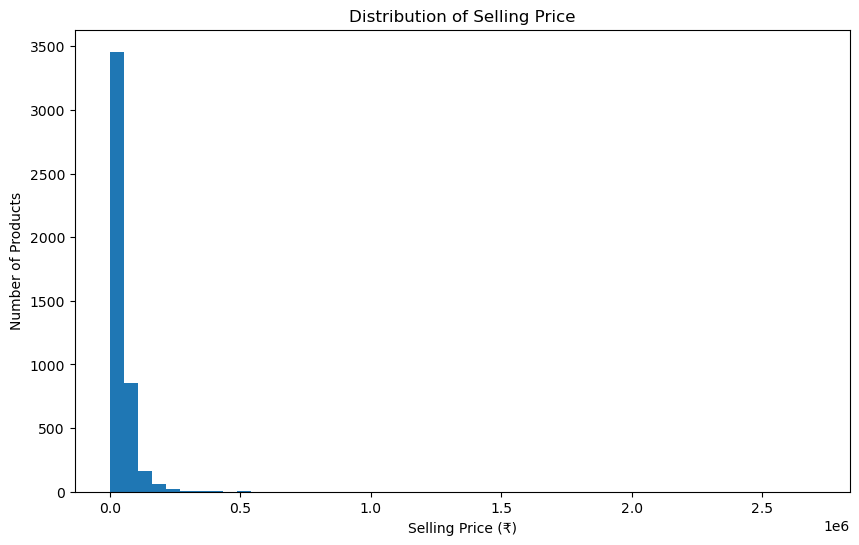

In [6]:
# ================================================================
# SELLING PRICE DISTRIBUTION
# ================================================================

plt.figure(figsize=(10, 6))

plt.hist(
    df["selling_price"].dropna(),
    bins=50
)

plt.title(
    "Distribution of Selling Price"
)

plt.xlabel(
    "Selling Price (₹)"
)

plt.ylabel(
    "Number of Products"
)

plt.show()

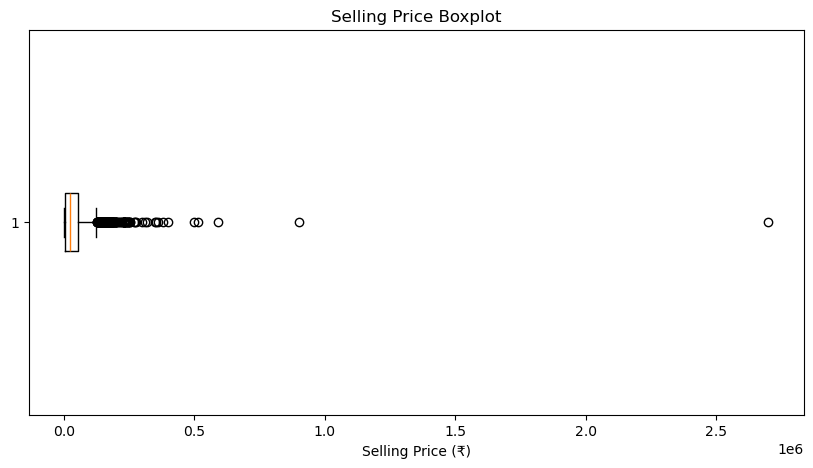

In [7]:
# ================================================================
# SELLING PRICE BOXPLOT
# ================================================================

plt.figure(figsize=(10, 5))

plt.boxplot(
    df["selling_price"].dropna(),
    vert=False
)

plt.title(
    "Selling Price Boxplot"
)

plt.xlabel(
    "Selling Price (₹)"
)

plt.show()

### Interpretation

The selling-price distribution is expected to be right-skewed because
the dataset contains products across multiple categories, ranging from
relatively inexpensive accessories to high-value electronics.

Potential high-price observations should not automatically be removed,
because premium laptops, televisions and other products can legitimately
have high prices.

The boxplot is therefore used primarily to identify observations that
require investigation.

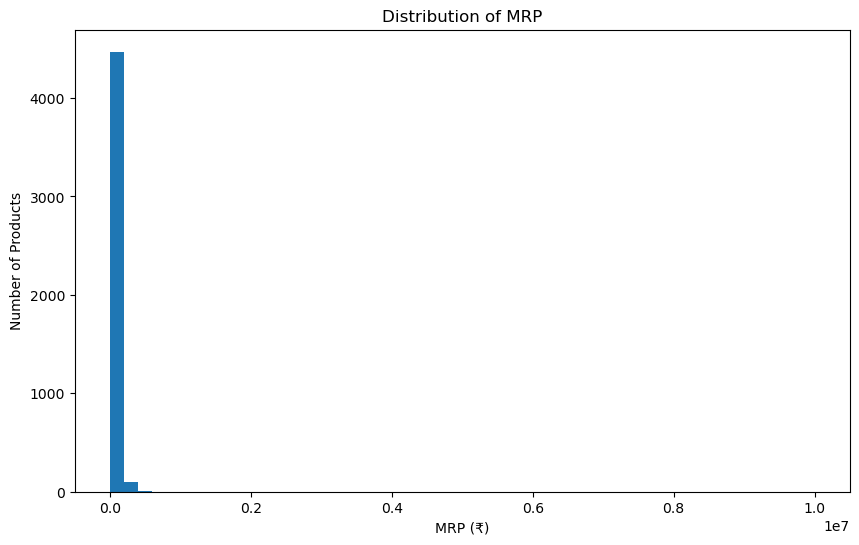

In [8]:
# ================================================================
# MRP DISTRIBUTION
# ================================================================

plt.figure(figsize=(10, 6))

plt.hist(
    df["mrp"].dropna(),
    bins=50
)

plt.title(
    "Distribution of MRP"
)

plt.xlabel(
    "MRP (₹)"
)

plt.ylabel(
    "Number of Products"
)

plt.show()

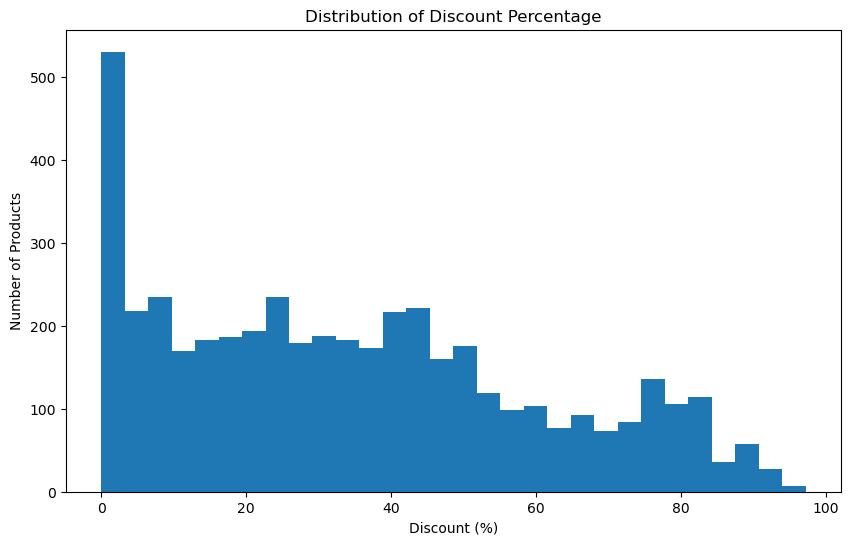

In [9]:
# ================================================================
# DISCOUNT DISTRIBUTION
# ================================================================

plt.figure(figsize=(10, 6))

plt.hist(
    df["discount_pct"].dropna(),
    bins=30
)

plt.title(
    "Distribution of Discount Percentage"
)

plt.xlabel(
    "Discount (%)"
)

plt.ylabel(
    "Number of Products"
)

plt.show()

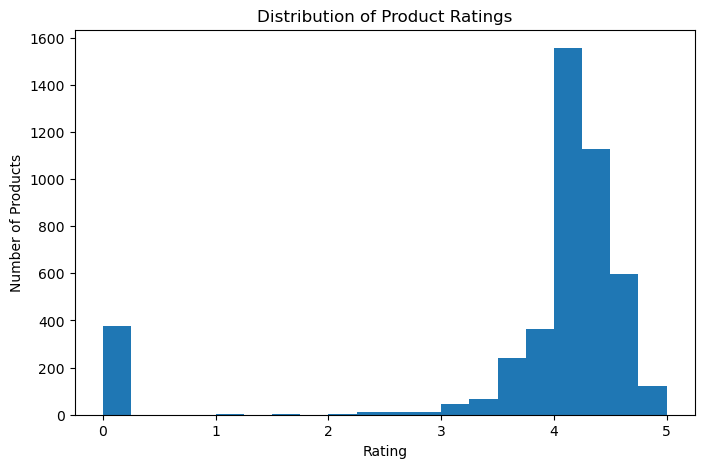

In [10]:
# ================================================================
# RATING DISTRIBUTION
# ================================================================

plt.figure(figsize=(8, 5))

plt.hist(
    df["rating"].dropna(),
    bins=20
)

plt.title(
    "Distribution of Product Ratings"
)

plt.xlabel(
    "Rating"
)

plt.ylabel(
    "Number of Products"
)

plt.show()

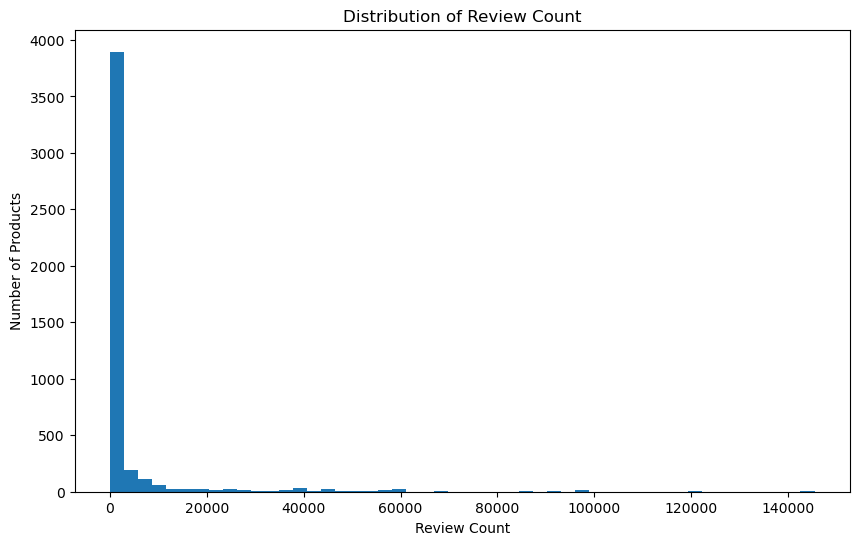

In [11]:
# ================================================================
# REVIEW COUNT DISTRIBUTION
# ================================================================

plt.figure(figsize=(10, 6))

plt.hist(
    df["review_count"].dropna(),
    bins=50
)

plt.title(
    "Distribution of Review Count"
)

plt.xlabel(
    "Review Count"
)

plt.ylabel(
    "Number of Products"
)

plt.show()

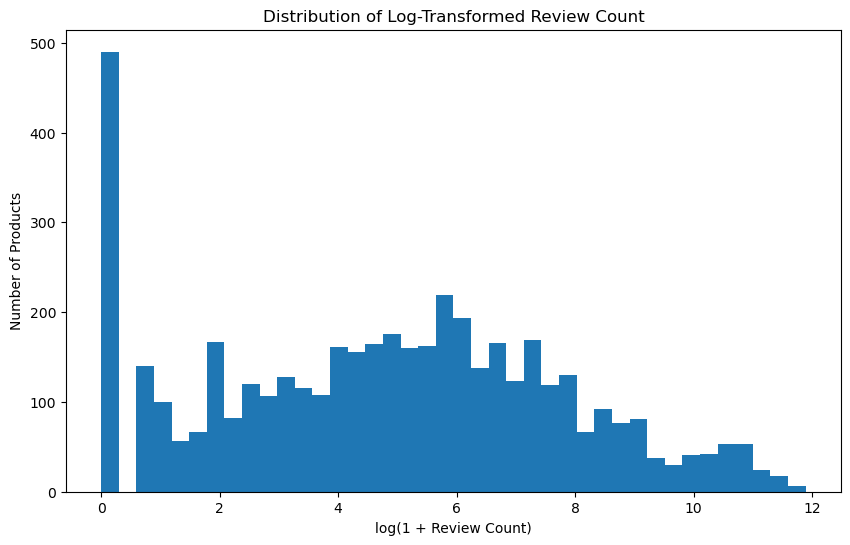

In [12]:
# ================================================================
# LOG-TRANSFORMED REVIEW COUNT
# ================================================================

review_data = (
    df["review_count"]
    .dropna()
)

log_review_count = np.log1p(
    review_data
)

plt.figure(figsize=(10, 6))

plt.hist(
    log_review_count,
    bins=40
)

plt.title(
    "Distribution of Log-Transformed Review Count"
)

plt.xlabel(
    "log(1 + Review Count)"
)

plt.ylabel(
    "Number of Products"
)

plt.show()

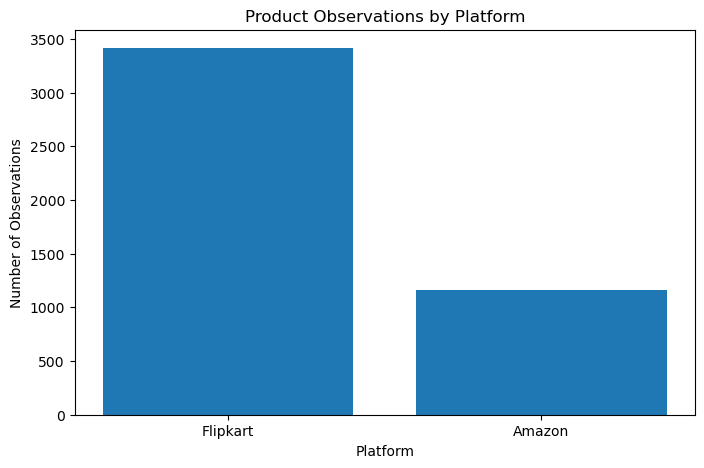

In [13]:
# ================================================================
# PLATFORM DISTRIBUTION
# ================================================================

platform_counts = (
    df["platform"]
    .value_counts()
)

plt.figure(figsize=(8, 5))

plt.bar(
    platform_counts.index,
    platform_counts.values
)

plt.title(
    "Product Observations by Platform"
)

plt.xlabel(
    "Platform"
)

plt.ylabel(
    "Number of Observations"
)

plt.show()

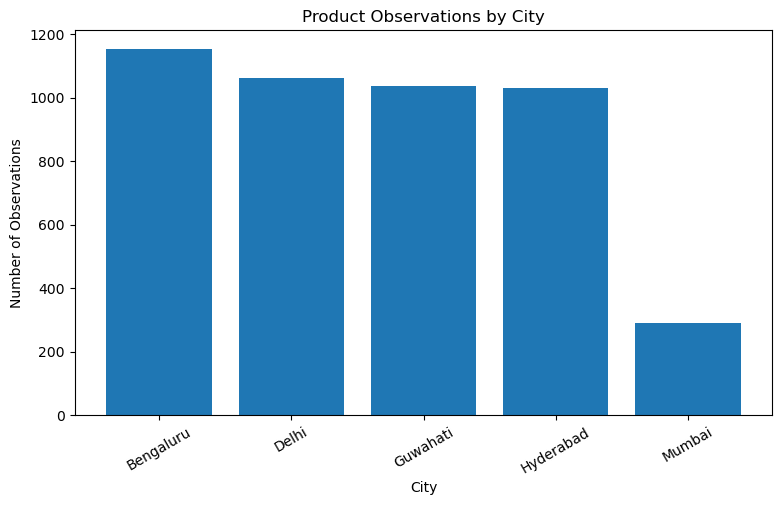

In [14]:
# ================================================================
# CITY DISTRIBUTION
# ================================================================

city_counts = (
    df["city"]
    .value_counts()
)

plt.figure(figsize=(9, 5))

plt.bar(
    city_counts.index,
    city_counts.values
)

plt.title(
    "Product Observations by City"
)

plt.xlabel(
    "City"
)

plt.ylabel(
    "Number of Observations"
)

plt.xticks(
    rotation=30
)

plt.show()

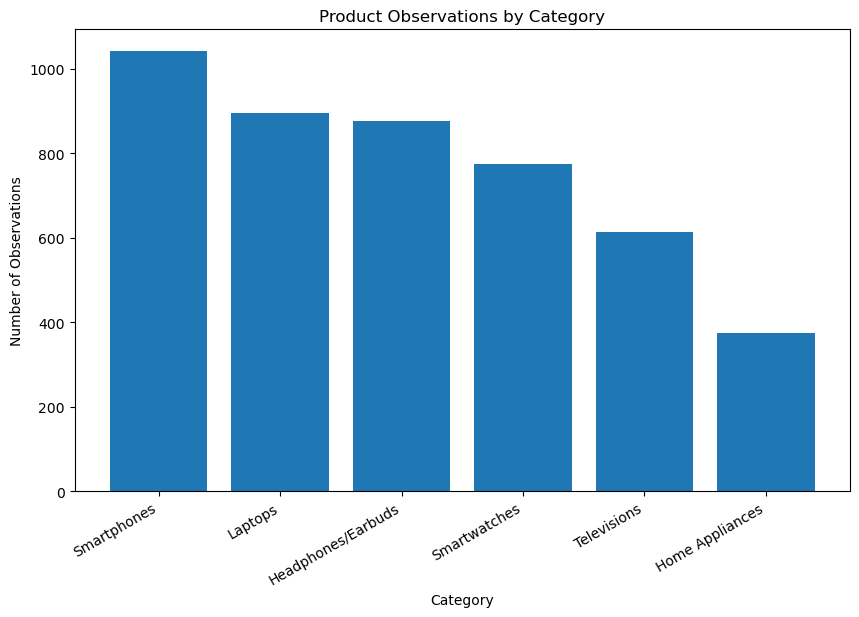

In [15]:
# ================================================================
# CATEGORY DISTRIBUTION
# ================================================================

category_counts = (
    df["category"]
    .value_counts()
)

plt.figure(figsize=(10, 6))

plt.bar(
    category_counts.index,
    category_counts.values
)

plt.title(
    "Product Observations by Category"
)

plt.xlabel(
    "Category"
)

plt.ylabel(
    "Number of Observations"
)

plt.xticks(
    rotation=30,
    ha="right"
)

plt.show()

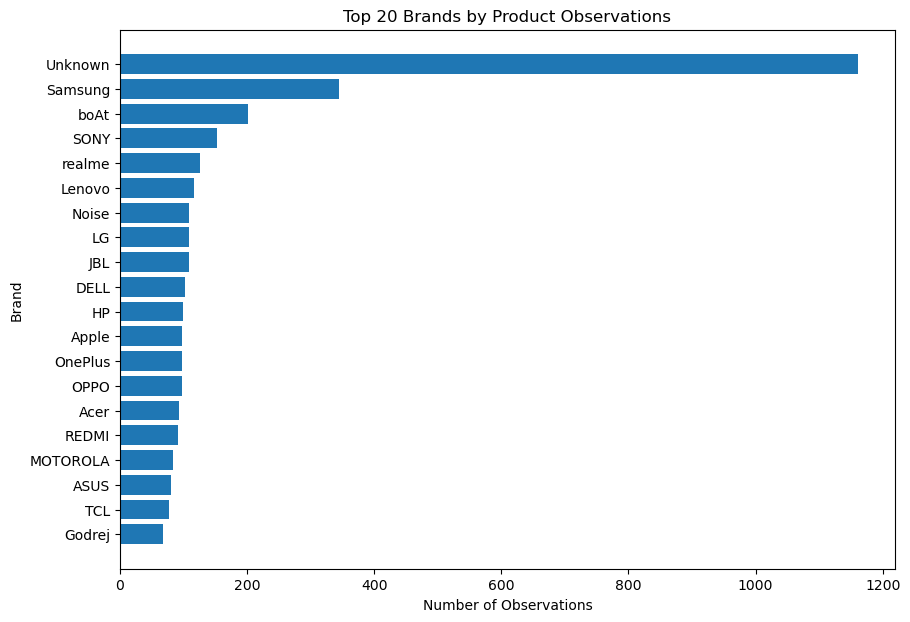

In [16]:
# ================================================================
# TOP 20 BRANDS
# ================================================================

top_brands = (
    df["brand"]
    .value_counts()
    .head(20)
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_brands.index[::-1],
    top_brands.values[::-1]
)

plt.title(
    "Top 20 Brands by Product Observations"
)

plt.xlabel(
    "Number of Observations"
)

plt.ylabel(
    "Brand"
)

plt.show()

# 4. Bivariate Analysis

Bivariate analysis investigates relationships between two variables.

For this E-Commerce project, the most important relationships are:

- Platform × Selling Price
- Platform × Discount
- Category × Selling Price
- Category × Discount
- City × Selling Price
- City × Discount
- Rating × Selling Price
- Review Count × Selling Price
- MRP × Selling Price

In [17]:
# ================================================================
# PLATFORM VS SELLING PRICE
# ================================================================

platform_price = (
    df.groupby("platform")["selling_price"]
    .agg(
        count="count",
        mean="mean",
        median="median",
        min="min",
        max="max"
    )
    .round(2)
)

display(
    platform_price
)

,count,mean,median,min,max
platform,,,,,
Amazon,1161,33720.31,21499.0,249.0,589990.0
Flipkart,3416,39054.69,24999.0,120.0,2699990.0


C:\Users\admin\AppData\Local\Temp\ipykernel_15060\3732742067.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


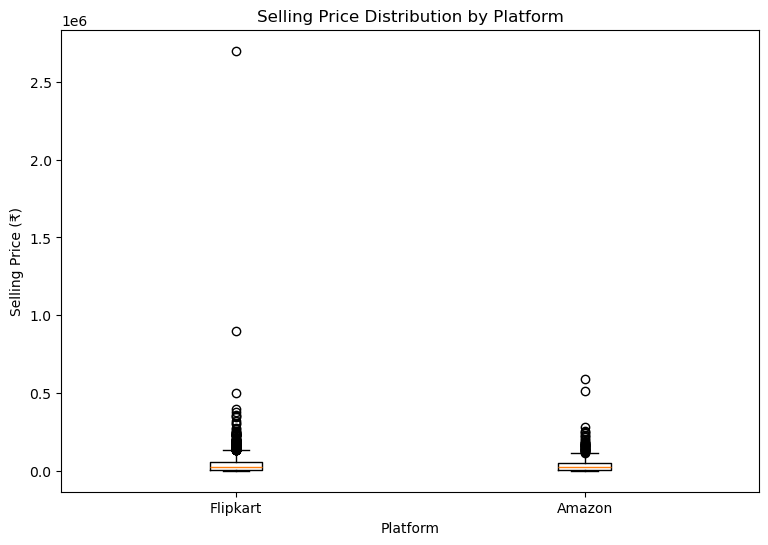

In [18]:
# ================================================================
# PLATFORM VS SELLING PRICE BOXPLOT
# ================================================================

platforms = df["platform"].dropna().unique()

price_by_platform = [
    df.loc[
        df["platform"] == platform,
        "selling_price"
    ].dropna()
    for platform in platforms
]

plt.figure(figsize=(9, 6))

plt.boxplot(
    price_by_platform,
    labels=platforms
)

plt.title(
    "Selling Price Distribution by Platform"
)

plt.xlabel(
    "Platform"
)

plt.ylabel(
    "Selling Price (₹)"
)

plt.show()

In [19]:
# ================================================================
# PLATFORM VS DISCOUNT
# ================================================================

platform_discount = (
    df.groupby("platform")["discount_pct"]
    .agg(
        count="count",
        mean="mean",
        median="median"
    )
    .round(2)
)

display(
    platform_discount
)

,count,mean,median
platform,,,
Amazon,1161,35.54,33.97
Flipkart,3416,34.48,31.43


C:\Users\admin\AppData\Local\Temp\ipykernel_15060\4151213498.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


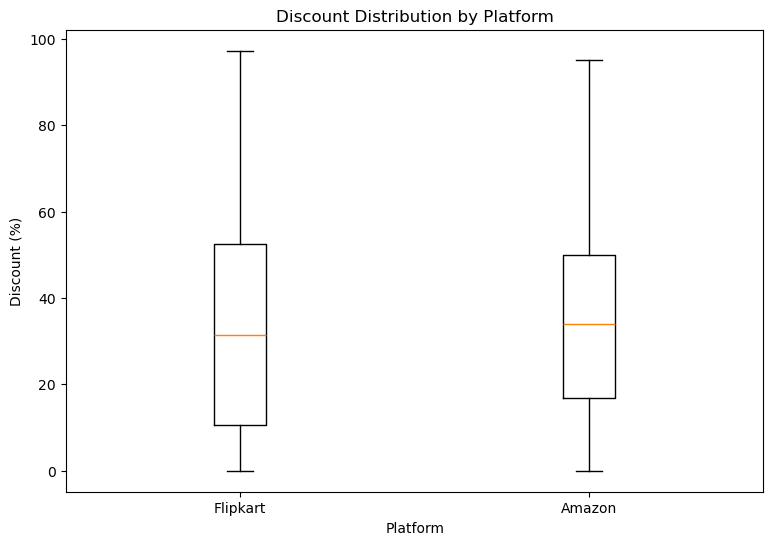

In [20]:
# ================================================================
# PLATFORM VS DISCOUNT BOXPLOT
# ================================================================

discount_by_platform = [
    df.loc[
        df["platform"] == platform,
        "discount_pct"
    ].dropna()
    for platform in platforms
]

plt.figure(figsize=(9, 6))

plt.boxplot(
    discount_by_platform,
    labels=platforms
)

plt.title(
    "Discount Distribution by Platform"
)

plt.xlabel(
    "Platform"
)

plt.ylabel(
    "Discount (%)"
)

plt.show()

In [21]:
# ================================================================
# CATEGORY VS SELLING PRICE
# ================================================================

category_price = (
    df.groupby("category")["selling_price"]
    .agg(
        count="count",
        mean="mean",
        median="median"
    )
    .sort_values(
        "median",
        ascending=False
    )
    .round(2)
)

display(
    category_price
)

,count,mean,median
category,,,
Laptops,895,84690.06,69890.0
Televisions,615,58784.99,42990.0
Smartphones,1041,34124.22,24999.0
Home Appliances,375,31254.03,22990.0
Smartwatches,774,11502.86,2499.0
Headphones/Earbuds,877,5088.87,1399.0


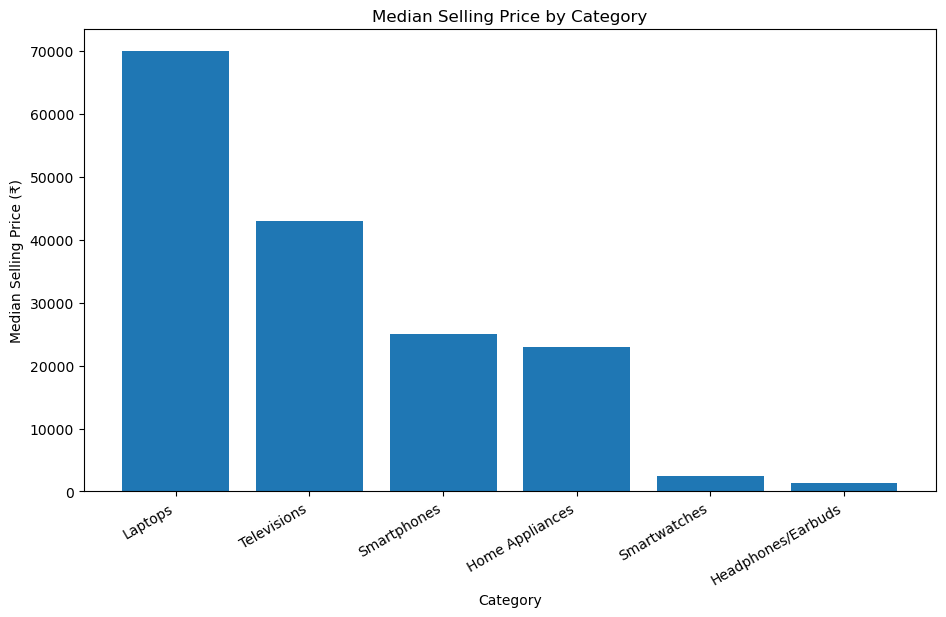

In [22]:
# ================================================================
# CATEGORY VS MEDIAN SELLING PRICE
# ================================================================

plt.figure(figsize=(11, 6))

plt.bar(
    category_price.index,
    category_price["median"]
)

plt.title(
    "Median Selling Price by Category"
)

plt.xlabel(
    "Category"
)

plt.ylabel(
    "Median Selling Price (₹)"
)

plt.xticks(
    rotation=30,
    ha="right"
)

plt.show()

In [23]:
# ================================================================
# CATEGORY VS DISCOUNT
# ================================================================

category_discount = (
    df.groupby("category")["discount_pct"]
    .agg(
        count="count",
        mean="mean",
        median="median"
    )
    .sort_values(
        "median",
        ascending=False
    )
    .round(2)
)

display(
    category_discount
)

,count,mean,median
category,,,
Smartwatches,774,54.35,62.87
Headphones/Earbuds,877,55.90,58.95
Televisions,615,36.98,37.70
Home Appliances,375,27.80,28.93
Smartphones,1041,19.27,16.04
Laptops,895,16.43,11.36


In [24]:
# ================================================================
# CITY VS SELLING PRICE
# ================================================================

city_price = (
    df.groupby("city")["selling_price"]
    .agg(
        count="count",
        mean="mean",
        median="median"
    )
    .sort_values(
        "median",
        ascending=False
    )
    .round(2)
)

display(
    city_price
)

,count,mean,median
city,,,
Bengaluru,1155,39929.56,28990.0
Delhi,1063,50257.75,27090.0
Hyderabad,1032,32414.57,21992.5
Mumbai,291,40795.61,18999.0
Guwahati,1036,26731.76,17994.0


In [25]:
# ================================================================
# CITY × PLATFORM SELLING PRICE
# ================================================================

city_platform_price = (
    df.groupby(
        ["city", "platform"]
    )["selling_price"]
    .agg(
        count="count",
        mean="mean",
        median="median"
    )
    .round(2)
)

display(
    city_platform_price
)

count      mean   median
city      platform                          
Bengaluru Amazon      307  33016.75  24499.0
          Flipkart    848  42432.20  31990.0
Delhi     Amazon      266  46891.86  24342.5
          Flipkart    797  51381.13  27999.0
Guwahati  Amazon      261  23701.11  14999.0
          Flipkart    775  27752.41  19999.0
Hyderabad Amazon      267  29858.45  21299.0
          Flipkart    765  33306.71  21999.0
Mumbai    Amazon       60  39695.18  21492.0
          Flipkart    231  41081.43  18495.0

platform,Amazon,Flipkart
city,,
Bengaluru,24499.0,31990.0
Delhi,24342.5,27999.0
Guwahati,14999.0,19999.0
Hyderabad,21299.0,21999.0
Mumbai,21492.0,18495.0


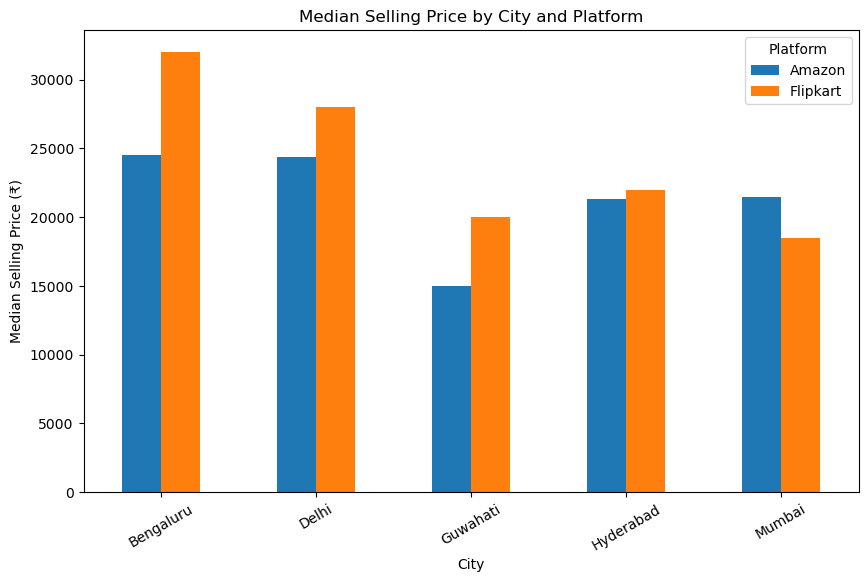

In [26]:
# ================================================================
# CITY × PLATFORM MEDIAN PRICE
# ================================================================

pivot_city_platform = (
    df.pivot_table(
        index="city",
        columns="platform",
        values="selling_price",
        aggfunc="median"
    )
)

display(
    pivot_city_platform
)

pivot_city_platform.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title(
    "Median Selling Price by City and Platform"
)

plt.xlabel(
    "City"
)

plt.ylabel(
    "Median Selling Price (₹)"
)

plt.xticks(
    rotation=30
)

plt.legend(
    title="Platform"
)

plt.show()

In [27]:
# ================================================================
# PLATFORM × CATEGORY
# ================================================================

platform_category = (
    df.pivot_table(
        index="category",
        columns="platform",
        values="selling_price",
        aggfunc="median"
    )
)

display(
    platform_category
)

platform,Amazon,Flipkart
category,,
Headphones/Earbuds,2599.0,1187.0
Home Appliances,17990.0,24990.0
Laptops,59990.0,72688.0
Smartphones,21990.5,25999.0
Smartwatches,2799.0,2499.0
Televisions,35990.0,44990.0


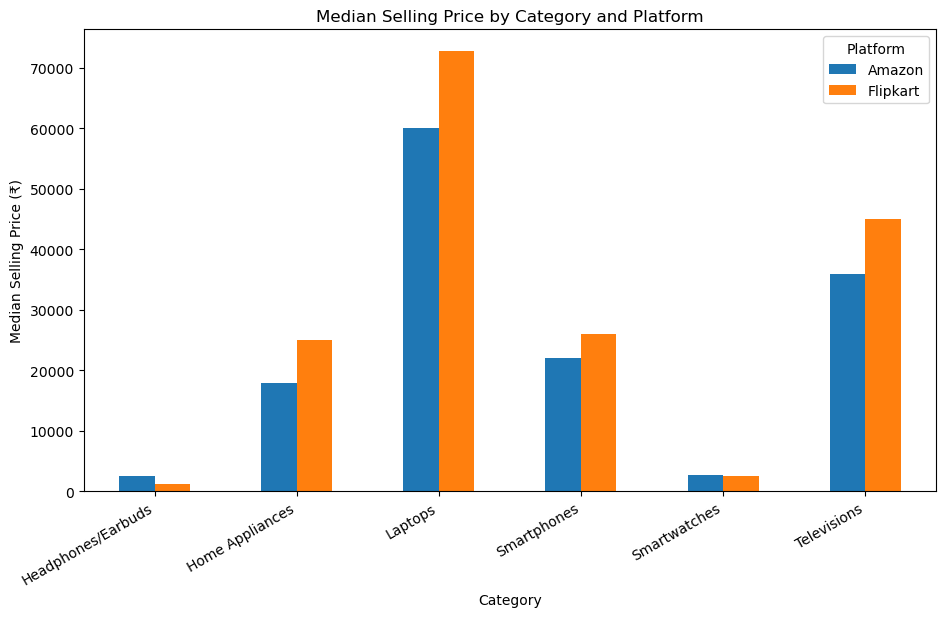

In [28]:
# ================================================================
# PLATFORM × CATEGORY VISUALIZATION
# ================================================================

platform_category.plot(
    kind="bar",
    figsize=(11, 6)
)

plt.title(
    "Median Selling Price by Category and Platform"
)

plt.xlabel(
    "Category"
)

plt.ylabel(
    "Median Selling Price (₹)"
)

plt.xticks(
    rotation=30,
    ha="right"
)

plt.legend(
    title="Platform"
)

plt.show()

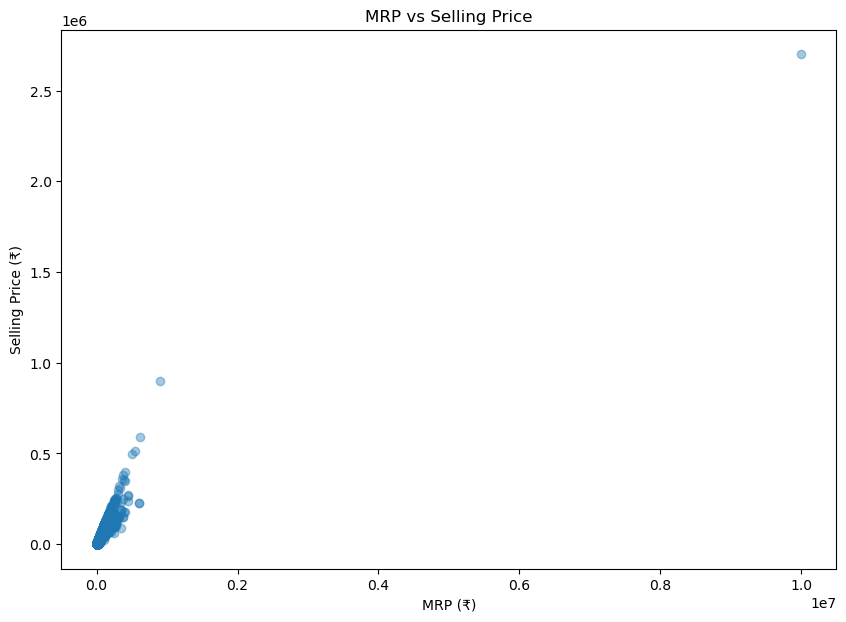

In [29]:
# ================================================================
# MRP VS SELLING PRICE
# ================================================================

plt.figure(figsize=(10, 7))

plt.scatter(
    df["mrp"],
    df["selling_price"],
    alpha=0.4
)

plt.title(
    "MRP vs Selling Price"
)

plt.xlabel(
    "MRP (₹)"
)

plt.ylabel(
    "Selling Price (₹)"
)

plt.show()

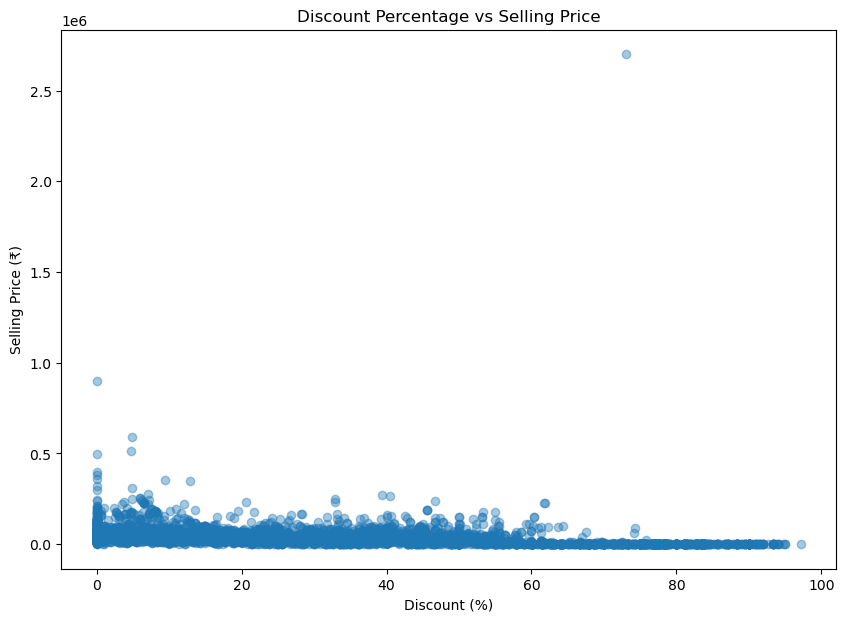

In [30]:
# ================================================================
# DISCOUNT VS SELLING PRICE
# ================================================================

plt.figure(figsize=(10, 7))

plt.scatter(
    df["discount_pct"],
    df["selling_price"],
    alpha=0.4
)

plt.title(
    "Discount Percentage vs Selling Price"
)

plt.xlabel(
    "Discount (%)"
)

plt.ylabel(
    "Selling Price (₹)"
)

plt.show()

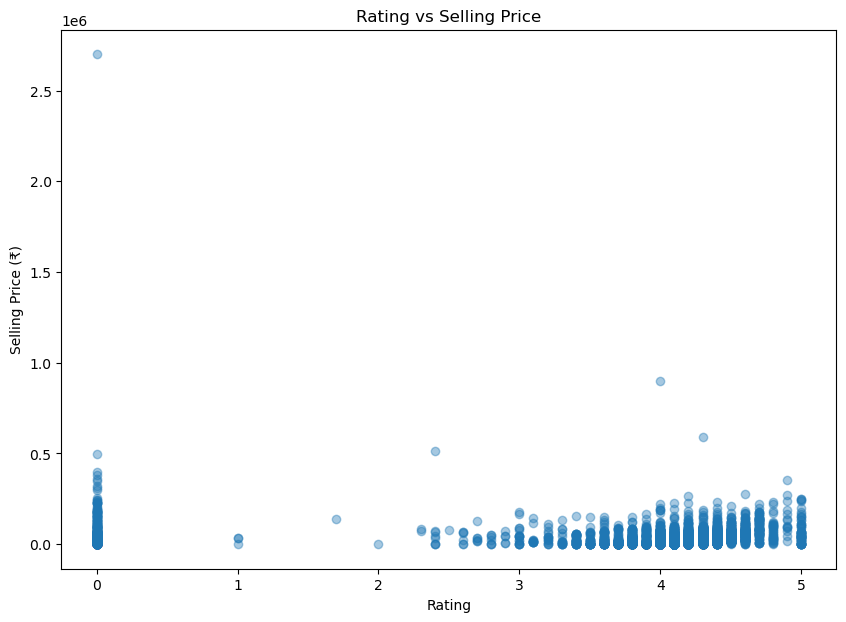

In [31]:
# ================================================================
# RATING VS SELLING PRICE
# ================================================================

plt.figure(figsize=(10, 7))

plt.scatter(
    df["rating"],
    df["selling_price"],
    alpha=0.4
)

plt.title(
    "Rating vs Selling Price"
)

plt.xlabel(
    "Rating"
)

plt.ylabel(
    "Selling Price (₹)"
)

plt.show()

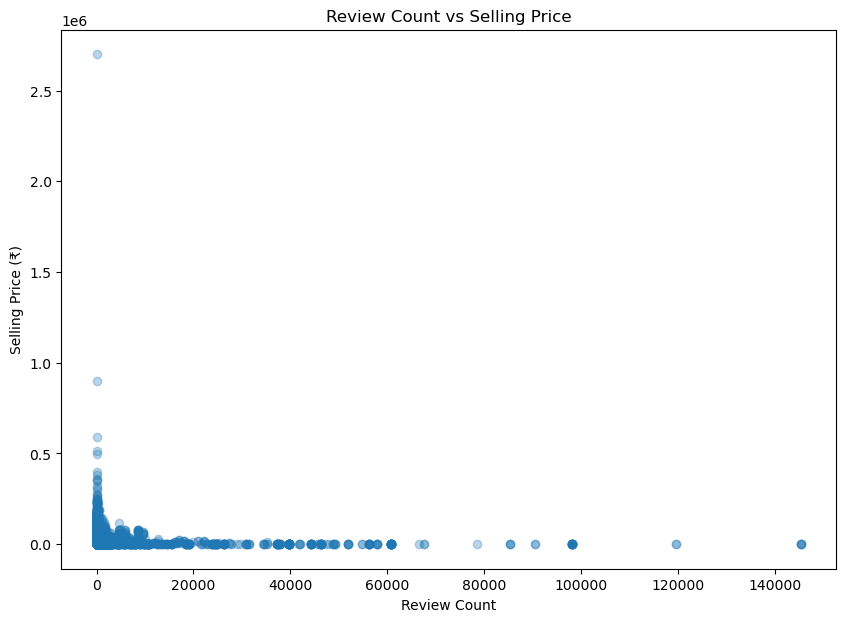

In [32]:
# ================================================================
# REVIEW COUNT VS SELLING PRICE
# ================================================================

plt.figure(figsize=(10, 7))

plt.scatter(
    df["review_count"],
    df["selling_price"],
    alpha=0.3
)

plt.title(
    "Review Count vs Selling Price"
)

plt.xlabel(
    "Review Count"
)

plt.ylabel(
    "Selling Price (₹)"
)

plt.show()

# 5. Multivariate Analysis

Multivariate analysis examines how multiple variables interact.

For this project, we focus on:

- Price
- MRP
- Discount
- Rating
- Review count
- Platform
- City
- Category

The objective is to identify patterns that cannot be observed from
single-variable analysis alone.

In [34]:
# ================================================================
# CORRELATION MATRIX
# ================================================================

correlation_columns = [
    "mrp",
    "selling_price",
    "discount_pct",
    "rating",
    "review_count"
]

correlation_matrix = (
    df[correlation_columns]
    .corr()
    .round(2)
)

display(
    correlation_matrix
)

,mrp,selling_price,discount_pct,rating,review_count
mrp,1.00,0.87,-0.09,-0.06,-0.07
selling_price,0.87,1.00,-0.33,-0.09,-0.15
discount_pct,-0.09,-0.33,1.00,-0.09,0.30
rating,-0.06,-0.09,-0.09,1.00,0.07
review_count,-0.07,-0.15,0.30,0.07,1.00


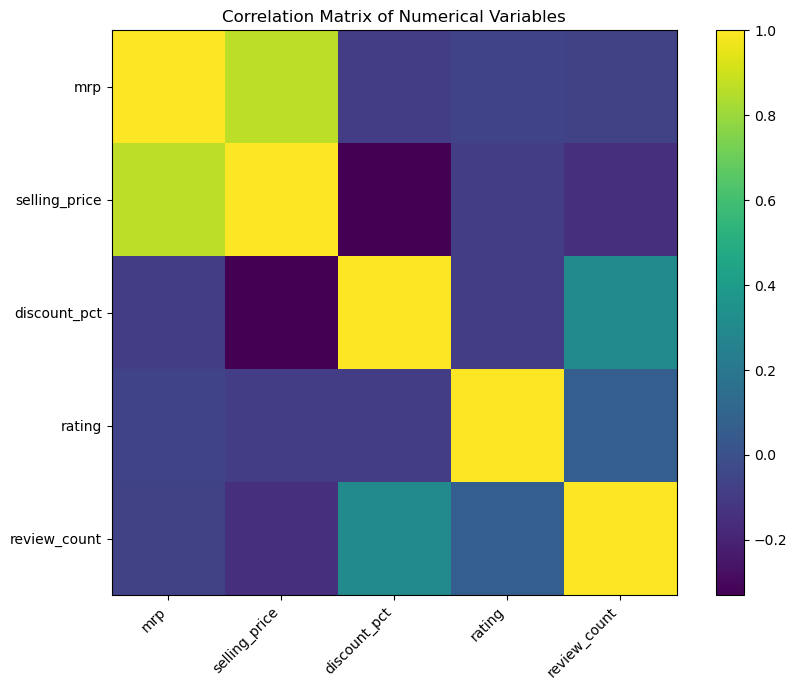

In [35]:
# ================================================================
# CORRELATION HEATMAP
# ================================================================

plt.figure(figsize=(9, 7))

plt.imshow(
    correlation_matrix,
    interpolation="nearest"
)

plt.colorbar()

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.title(
    "Correlation Matrix of Numerical Variables"
)

plt.tight_layout()

plt.show()

In [36]:
# ================================================================
# PLATFORM × CITY × CATEGORY ANALYSIS
# ================================================================

platform_city_category = (
    df.groupby(
        [
            "platform",
            "city",
            "category"
        ]
    )
    .agg(
        product_count=(
            "product_id",
            "nunique"
        ),
        median_price=(
            "selling_price",
            "median"
        ),
        avg_discount=(
            "discount_pct",
            "mean"
        ),
        avg_rating=(
            "rating",
            "mean"
        )
    )
    .reset_index()
)

display(
    platform_city_category.head(30)
)

,platform,city,category,product_count,median_price,avg_discount,avg_rating
0,Amazon,Bengaluru,Headphones/Earbuds,53,1499.0,55.241321,4.005660
1,Amazon,Bengaluru,Home Appliances,41,19990.0,23.410000,4.002500
2,Amazon,Bengaluru,Laptops,63,54890.0,28.867619,3.847273
3,Amazon,Bengaluru,Smartphones,59,28299.0,20.116610,4.086441
4,Amazon,Bengaluru,Smartwatches,48,2173.5,62.932917,4.039583
5,Amazon,Bengaluru,Televisions,43,36490.0,32.262326,4.211628
6,Amazon,Delhi,Headphones/Earbuds,40,7589.5,35.835250,3.977500
7,Amazon,Delhi,Home Appliances,42,17089.5,36.601429,3.926829
8,Amazon,Delhi,Laptops,59,82990.0,19.334407,4.064151
9,Amazon,Delhi,Smartphones,62,22998.5,20.316452,4.125806


In [37]:
# ================================================================
# HIGHEST MEDIAN PRICE SEGMENTS
# ================================================================

top_price_segments = (
    platform_city_category
    .sort_values(
        "median_price",
        ascending=False
    )
    .head(20)
)

display(
    top_price_segments
)

,platform,city,category,product_count,median_price,avg_discount,avg_rating
24,Amazon,Mumbai,Laptops,6,171490.0,11.830000,3.866667
36,Flipkart,Delhi,Laptops,178,108340.0,8.703315,3.387079
8,Amazon,Delhi,Laptops,59,82990.0,19.334407,4.064151
46,Flipkart,Hyderabad,Laptops,156,73829.5,13.920000,3.639103
30,Flipkart,Bengaluru,Laptops,153,68490.0,19.509216,4.111111
18,Amazon,Hyderabad,Laptops,63,64990.0,22.611746,3.827586
52,Flipkart,Mumbai,Laptops,6,62985.0,14.745000,3.583333
41,Flipkart,Guwahati,Laptops,148,59990.0,11.940878,3.654054
33,Flipkart,Bengaluru,Televisions,142,59990.0,35.171408,3.522535
2,Amazon,Bengaluru,Laptops,63,54890.0,28.867619,3.847273


In [38]:
# ================================================================
# HIGHEST DISCOUNT SEGMENTS
# ================================================================

top_discount_segments = (
    platform_city_category
    .sort_values(
        "avg_discount",
        ascending=False
    )
    .head(20)
)

display(
    top_discount_segments
)

,platform,city,category,product_count,median_price,avg_discount,avg_rating
50,Flipkart,Mumbai,Headphones/Earbuds,48,475.0,67.889792,1.779167
48,Flipkart,Hyderabad,Smartwatches,150,1699.0,64.397600,4.153333
4,Amazon,Bengaluru,Smartwatches,48,2173.5,62.932917,4.039583
20,Amazon,Hyderabad,Smartwatches,59,1999.0,61.714576,4.086207
45,Flipkart,Hyderabad,Headphones/Earbuds,176,999.0,61.698636,3.301136
32,Flipkart,Bengaluru,Smartwatches,115,1999.0,61.021652,4.084348
28,Flipkart,Bengaluru,Headphones/Earbuds,136,1249.0,59.945956,3.639706
15,Amazon,Guwahati,Smartwatches,63,2299.0,56.514444,3.965574
40,Flipkart,Guwahati,Headphones/Earbuds,183,1399.0,55.877268,3.745902
34,Flipkart,Delhi,Headphones/Earbuds,113,2699.0,55.450000,3.386726


# 6. Feature Engineering Ideas

The following analytical features are useful for the business problem:

### Price Gap

Difference between MRP and selling price.

### Discount Recalculation

Discount independently calculated from MRP and selling price.

### Price Position

Position of a product relative to the median price within its category.

### Review Engagement

Log-transformed review count to handle extreme skew.

These features will be useful in the business-analysis stage.

In [39]:
# ================================================================
# PRICE GAP
# ================================================================

df["price_gap"] = (
    df["mrp"]
    -
    df["selling_price"]
)

display(
    df[
        [
            "mrp",
            "selling_price",
            "price_gap"
        ]
    ].head()
)

,mrp,selling_price,price_gap
0,18999.0,14999.0,4000.0
1,12499.0,9999.0,2500.0
2,11999.0,11499.0,500.0
3,49999.0,29999.0,20000.0
4,20999.0,16999.0,4000.0


In [40]:
# ================================================================
# RECALCULATED DISCOUNT
# ================================================================

df["calculated_discount_pct"] = (

    (
        df["mrp"]
        -
        df["selling_price"]
    )
    /
    df["mrp"]

) * 100

display(
    df[
        [
            "mrp",
            "selling_price",
            "discount_pct",
            "calculated_discount_pct"
        ]
    ].head()
)

,mrp,selling_price,discount_pct,calculated_discount_pct
0,18999.0,14999.0,21.05,21.053740
1,12499.0,9999.0,20.00,20.001600
2,11999.0,11499.0,4.17,4.167014
3,49999.0,29999.0,40.00,40.000800
4,20999.0,16999.0,19.05,19.048526


In [42]:
# ================================================================
# CATEGORY PRICE INDEX
# ================================================================
# < 1.0 → below category median
# = 1.0 → around category median
# > 1.0 → above category median

category_median_price = (
    df.groupby("category")["selling_price"]
    .transform("median")
)

df["category_price_index"] = (

    df["selling_price"]
    /
    category_median_price

)

display(
    df[
        [
            "category",
            "selling_price",
            "category_price_index"
        ]
    ].head(10)
)

,category,selling_price,category_price_index
0,Smartphones,14999.0,0.599984
1,Smartphones,9999.0,0.399976
2,Smartphones,11499.0,0.459978
3,Smartphones,29999.0,1.200008
4,Smartphones,16999.0,0.679987
5,Smartphones,13981.0,0.559262
6,Smartphones,11484.0,0.459378
7,Smartphones,26999.0,1.080003
8,Smartphones,15470.0,0.618825
9,Smartphones,15499.0,0.619985


In [43]:
# ================================================================
# LOG REVIEW COUNT
# ================================================================

df["log_review_count"] = np.log1p(
    df["review_count"]
)

display(
    df[
        [
            "review_count",
            "log_review_count"
        ]
    ].head()
)

,review_count,log_review_count
0,1049.0,6.956545
1,108.0,4.691348
2,655.0,6.486161
3,36.0,3.610918
4,760.0,6.634633


# 7. Competitive Pricing Exploration

The purpose of this section is to identify initial pricing patterns
that should be investigated in the formal business-analysis notebook.

Important:

This section does NOT make final stakeholder recommendations.

It identifies patterns and questions for:

`05_business_analysis.ipynb`

In [44]:
# ================================================================
# PLATFORM PRICE COMPARISON
# ================================================================

platform_summary = (
    df.groupby("platform")
    .agg(
        products=(
            "product_id",
            "nunique"
        ),
        average_price=(
            "selling_price",
            "mean"
        ),
        median_price=(
            "selling_price",
            "median"
        ),
        average_discount=(
            "discount_pct",
            "mean"
        ),
        average_rating=(
            "rating",
            "mean"
        )
    )
    .round(2)
)

display(
    platform_summary
)

,products,average_price,median_price,average_discount,average_rating
platform,,,,,
Amazon,880,33720.31,21499.0,35.54,4.01
Flipkart,2687,39054.69,24999.0,34.48,3.77


In [45]:
# ================================================================
# CATEGORY × PLATFORM SUMMARY
# ================================================================

category_platform_summary = (
    df.groupby(
        [
            "category",
            "platform"
        ]
    )
    .agg(
        products=(
            "product_id",
            "nunique"
        ),
        median_price=(
            "selling_price",
            "median"
        ),
        average_discount=(
            "discount_pct",
            "mean"
        ),
        average_rating=(
            "rating",
            "mean"
        )
    )
    .reset_index()
)

display(
    category_platform_summary
)

,category,platform,products,median_price,average_discount,average_rating
0,Headphones/Earbuds,Amazon,166,2599.0,46.443167,4.006787
1,Headphones/Earbuds,Flipkart,478,1187.0,59.087973,3.398780
2,Home Appliances,Amazon,88,17990.0,30.287273,3.958140
3,Home Appliances,Flipkart,287,24990.0,27.037875,3.645645
4,Laptops,Amazon,179,59990.0,24.190551,3.861842
5,Laptops,Flipkart,565,72688.0,13.356225,3.684711
6,Smartphones,Amazon,188,21990.5,22.914920,4.041393
7,Smartphones,Flipkart,598,25999.0,18.124324,4.241846
8,Smartwatches,Amazon,151,2799.0,55.462654,4.060577
9,Smartwatches,Flipkart,382,2499.0,53.933552,3.737300


In [46]:
# ================================================================
# CITY × PLATFORM SUMMARY
# ================================================================

city_platform_summary = (
    df.groupby(
        [
            "city",
            "platform"
        ]
    )
    .agg(
        products=(
            "product_id",
            "nunique"
        ),
        median_price=(
            "selling_price",
            "median"
        ),
        average_discount=(
            "discount_pct",
            "mean"
        ),
        average_rating=(
            "rating",
            "mean"
        )
    )
    .reset_index()
)

display(
    city_platform_summary
)

,city,platform,products,median_price,average_discount,average_rating
0,Bengaluru,Amazon,307,24499.0,36.811726,4.027181
1,Bengaluru,Flipkart,848,31990.0,33.246108,3.945047
2,Delhi,Amazon,266,24342.5,29.144248,4.058301
3,Delhi,Flipkart,797,27999.0,29.439197,3.515182
4,Guwahati,Amazon,261,14999.0,38.650307,3.942913
5,Guwahati,Flipkart,775,19999.0,34.993935,3.940645
6,Hyderabad,Amazon,267,21299.0,38.479700,4.002756
7,Hyderabad,Flipkart,765,21999.0,39.488850,3.818431
8,Mumbai,Amazon,60,21492.0,30.753167,3.965455
9,Mumbai,Flipkart,231,18495.0,38.028874,3.221212


## Important EDA Finding: Comparable Products

Platform-level average price provides a useful descriptive view, but
it is not sufficient to determine competitive pricing.

A stronger comparison requires matching the same product across
platforms.

Therefore, the next business-analysis stage will create a comparable
product dataset using:

- Product identity
- Product name
- Brand
- Variant
- Category
- Product identifiers where available

The analysis will then compare Amazon and Flipkart prices for comparable
products.

In [47]:
# ================================================================
# AUTOMATED EDA SUMMARY TABLE
# ================================================================

eda_summary = pd.DataFrame({

    "metric": [
        "Total observations",
        "Unique products",
        "Platforms",
        "Cities",
        "Categories",
        "Average selling price",
        "Median selling price",
        "Average discount",
        "Average rating"
    ],

    "value": [
        len(df),
        df["product_id"].nunique(),
        df["platform"].nunique(),
        df["city"].nunique(),
        df["category"].nunique(),
        round(df["selling_price"].mean(), 2),
        round(df["selling_price"].median(), 2),
        round(df["discount_pct"].mean(), 2),
        round(df["rating"].mean(), 2)
    ]

})

display(
    eda_summary
)

,metric,value
0,Total observations,4577.00
1,Unique products,3567.00
2,Platforms,2.00
3,Cities,5.00
4,Categories,6.00
5,Average selling price,37701.57
6,Median selling price,23990.00
7,Average discount,34.75
8,Average rating,3.83


# 8. Key EDA Findings

### Dataset Coverage

The dataset contains observations from two major E-Commerce
marketplaces across five Indian cities and six major product categories.

### Platform Coverage

The number of observations is not evenly distributed between Amazon
and Flipkart. Therefore, platform-level descriptive statistics should
be interpreted with the difference in coverage in mind.

### Pricing

Selling prices show substantial dispersion because the dataset covers
multiple electronics categories with different price ranges.

### Discount

Discount levels vary considerably across products and categories,
suggesting that discount strategy may differ by product segment.

### Customer Signals

Ratings are concentrated toward the higher end of the rating scale,
while review counts are highly skewed.

### City Differences

Product coverage differs across cities, with Mumbai having fewer
observations than the other cities. City-level comparisons should
therefore consider sample-size differences.

### Competitive Pricing

Simple platform-level average prices are insufficient to determine
which marketplace is cheaper. Comparable-product analysis is required
and will be performed in the business-analysis stage.

# 9. Next Steps

The EDA has identified the major pricing, product, platform, category
and city-level patterns.

The next stage is stakeholder-focused business analysis.

## `05_business_analysis.ipynb`

The business-analysis stage will answer questions such as:

1. Which platform is more price competitive for comparable products?
2. Which categories have the largest competitive price gaps?
3. Which brands have significant pricing differences?
4. Which cities show the largest platform-level price differences?
5. Where are discounts most aggressive?
6. Which products require pricing attention?
7. Which platform has an advantage within each category?
8. Are there specific city-category combinations with pricing
   opportunities?

The outputs from business analysis will then be used to design the
analytical data model and star schema.